In [2]:
from google.colab import files
uploaded = files.upload()

Saving dataset_v2.csv to dataset_v2.csv


In [3]:
import pandas as pd

df = pd.read_csv("dataset_v2.csv")
print(df.shape)
print(df["label"].value_counts())

(206241, 9)
label
2    100109
0     76429
1     29703
Name: count, dtype: int64


In [4]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

df["timestamp"] = pd.to_datetime(df["timestamp"])
df["timestamp"] = df["timestamp"].astype(np.int64) // 10**9

df["label"] = df["label"].apply(lambda x: 0 if x in [0, 1] else 1)

print("Label distribution:")
print(df["label"].value_counts())

features = ["timestamp", "status_code", "response_size",
            "requests_per_second", "has_suspicious_chars", "is_known_path"]

X = df[features].values
y = df["label"].values

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

TIMESTEPS = 10

def create_sequences(X, y, timesteps):
    Xs, ys = [], []
    for i in range(len(X) - timesteps):
        Xs.append(X[i:i+timesteps])
        ys.append(y[i+timesteps])
    return np.array(Xs), np.array(ys)

print("Creating sequences...")
X_seq, y_seq = create_sequences(X_scaled, y, TIMESTEPS)

print(f"X shape: {X_seq.shape}")
print(f"y shape: {y_seq.shape}")

X_train, X_test, y_train, y_test = train_test_split(
    X_seq, y_seq, test_size=0.3, random_state=42
)

print(f"Train: {X_train.shape}")
print(f"Test: {X_test.shape}")

Label distribution:
label
0    106132
1    100109
Name: count, dtype: int64
Creating sequences...
X shape: (206231, 10, 6)
y shape: (206231,)
Train: (144361, 10, 6)
Test: (61870, 10, 6)


In [5]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

model = Sequential([
    Input(shape=(TIMESTEPS, len(features))),
    LSTM(64, return_sequences=True),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(16, activation="relu"),
    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 10, 64)         │        18,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,137 (121.63 KB)

 Trainable params: 31,137 (121.63 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
1805/1805 ━━━━━━━━━━━━━━━━━━━━ 34s 17ms/step - accuracy: 0.9958 - loss: 0.0155 - val_accuracy: 1.0000 - val_loss: 4.5298e-04
Epoch 2/20
1805/1805 ━━━━━━━━━━━━━━━━━━━━ 30s 16ms/step - accuracy: 1.0000 - loss: 4.2782e-04 - val_accuracy: 1.0000 - val_loss: 3.7831e-04
Epoch 3/20
1805/1805 ━━━━━━━━━━━━━━━━━━━━ 29s 16ms/step - accuracy: 0.9994 - loss: 0.0032 - val_accuracy: 1.0000 - val_loss: 3.9208e-04
Epoch 4/20
1805/1805 ━━━━━━━━━━━━━━━━━━━━ 29s 16ms/step - accuracy: 0.9999 - loss: 4.7195e-04 - val_accuracy: 1.0000 - val_loss: 3.8881e-04
Epoch 5/20
1805/1805 ━━━━━━━━━━━━━━━━━━━━ 30s 17ms/step - accuracy: 1.0000 - loss: 3.4888e-04 - val_accuracy: 1.0000 - val_loss: 4.1380e-04


1934/1934 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step
MODELIO REZULTATAI
Accuracy:  0.9999
Precision: 1.0000
Recall:    0.9999
F1 Score:  0.9999

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     31683
     Anomaly       1.00      1.00      1.00     30187

    accuracy                           1.00     61870
   macro avg       1.00      1.00      1.00     61870
weighted avg       1.00      1.00      1.00     61870

KONFUZIJOS MATRICA
True Positive  (TP): 30183
True Negative  (TN): 31683
False Positive (FP): 0
False Negative (FN): 4


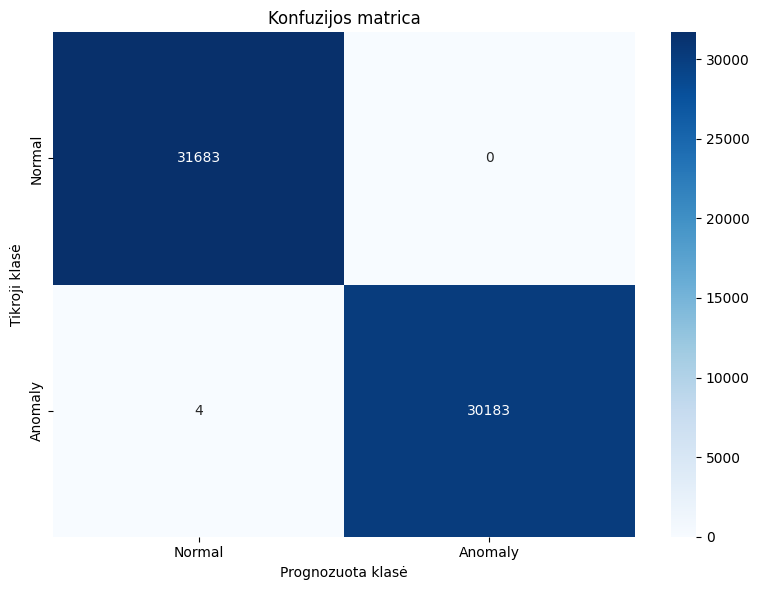

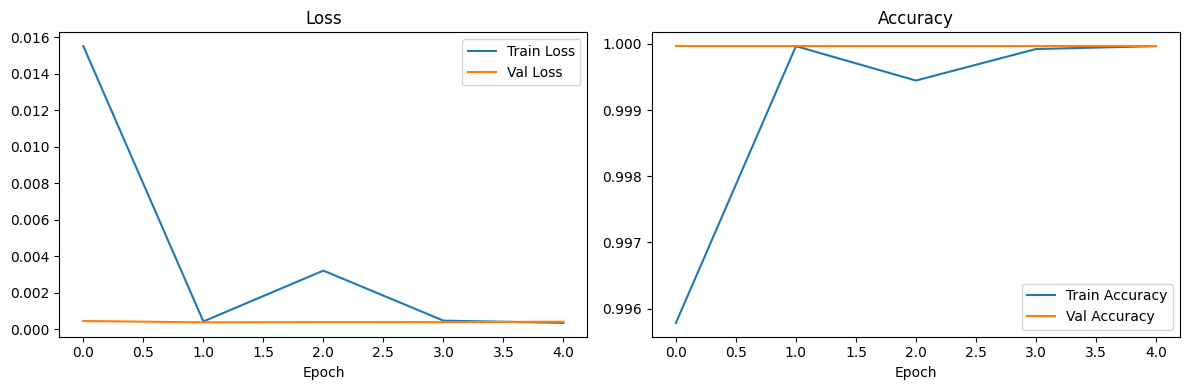

In [7]:
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, precision_score,
                              recall_score, f1_score)
import matplotlib.pyplot as plt
import seaborn as sns

y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("=" * 40)
print("MODELIO REZULTATAI")
print("=" * 40)
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred,
      target_names=["Normal", "Anomaly"]))

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print("=" * 40)
print("KONFUZIJOS MATRICA")
print("=" * 40)
print(f"True Positive  (TP): {tp}")
print(f"True Negative  (TN): {tn}")
print(f"False Positive (FP): {fp}")
print(f"False Negative (FN): {fn}")

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Normal", "Anomaly"],
            yticklabels=["Normal", "Anomaly"])
plt.title("Konfuzijos matrica")
plt.ylabel("Tikroji klasė")
plt.xlabel("Prognozuota klasė")
plt.tight_layout()
plt.show()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history["loss"], label="Train Loss")
ax1.plot(history.history["val_loss"], label="Val Loss")
ax1.set_title("Loss")
ax1.set_xlabel("Epoch")
ax1.legend()

ax2.plot(history.history["accuracy"], label="Train Accuracy")
ax2.plot(history.history["val_accuracy"], label="Val Accuracy")
ax2.set_title("Accuracy")
ax2.set_xlabel("Epoch")
ax2.legend()

plt.tight_layout()
plt.show()